# Credit Card Fraud Detection
### COM 763 — Advanced Machine Learning 
### Portfolio Task 1

**Objective:** Build, evaluate, and select a machine learning model that accurately detects credit card fraud.
---
**Dataset:** Credit Card Fraud Dataset — Western United States  
**Source:** [https://www.kaggle.com/datasets/dhruvb2028/credit-card-fraud-dataset/data](https://www.kaggle.com/datasets/dhruvb2028/credit-card-fraud-dataset/data)


## 1. Import

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Charts and Graphs
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px


from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder


from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier


from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, precision_recall_curve, f1_score,
    precision_score, recall_score
)

# Style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120



## 2. Loading and Inspecting the Dataset


In [2]:
# Load dataset
df = pd.read_csv('credit_card_frauds.csv')  

print(f"Total records : {len(df):,}")
print(f"Columns       : {df.shape[1]}")
print(f"\nColumn names:\n{df.columns.tolist()}")

Total records : 339,607
Columns       : 15

Column names:
['trans_date_trans_time', 'merchant', 'category', 'amt', 'city', 'state', 'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'merch_lat', 'merch_long', 'is_fraud']


In [3]:
df.head(5)


,trans_date_trans_time,merchant,category,amt,city,state,lat,long,city_pop,job,dob,trans_num,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:44,"Heller, Gutmann and Zieme",grocery_pos,107.23,Orient,WA,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,49.159047,-118.186462,0
1,2019-01-01 00:00:51,Lind-Buckridge,entertainment,220.11,Malad City,ID,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,43.150704,-112.154481,0
2,2019-01-01 00:07:27,Kiehn Inc,grocery_pos,96.29,Grenada,CA,41.6125,-122.5258,589,Systems analyst,1945-12-21,413636e759663f264aae1819a4d4f231,41.657520,-122.230347,0
3,2019-01-01 00:09:03,Beier-Hyatt,shopping_pos,7.77,High Rolls Mountain Park,NM,32.9396,-105.8189,899,Naval architect,1967-08-30,8a6293af5ed278dea14448ded2685fea,32.863258,-106.520205,0
4,2019-01-01 00:21:32,Bruen-Yost,misc_pos,6.85,Freedom,WY,43.0172,-111.0292,471,"Education officer, museum",1967-08-02,f3c43d336e92a44fc2fb67058d5949e3,43.753735,-111.454923,0


In [4]:
# Data types and nulls
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 339607 entries, 0 to 339606
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   trans_date_trans_time  339607 non-null  str    
 1   merchant               339607 non-null  str    
 2   category               339607 non-null  str    
 3   amt                    339607 non-null  float64
 4   city                   339607 non-null  str    
 5   state                  339607 non-null  str    
 6   lat                    339607 non-null  float64
 7   long                   339607 non-null  float64
 8   city_pop               339607 non-null  int64  
 9   job                    339607 non-null  str    
 10  dob                    339607 non-null  str    
 11  trans_num              339607 non-null  str    
 12  merch_lat              339607 non-null  float64
 13  merch_long             339607 non-null  float64
 14  is_fraud               339607 non-null  int64  

In [5]:
# Check for missing values
missing = df.isnull().sum()
print("Missing values per column:")
print(missing[missing > 0] if missing.sum() > 0 else "No missing values found.")


Missing values per column:
No missing values found.


In [6]:
# Class distribution
fraud_counts = df['is_fraud'].value_counts()
fraud_pct    = df['is_fraud'].value_counts(normalize=True) * 100

print("Class distribution:")
print(pd.DataFrame({'Count': fraud_counts, 'Percentage (%)': fraud_pct.round(2)}))


Class distribution:
           Count  Percentage (%)
is_fraud                        
0         337825           99.48
1           1782            0.52


## 3. Exploratory Data Analysis (EDA)

I have identified key questions to be answered by the dataset:
1. Which transaction categories have the highest fraud rates?
2. What is the transaction amount distribution for fraudulent vs legitimate transactions?
3. Are elderly customers more likely to be victims?
4. What does fraud look like geographically in western US?


### 3.1 Class Imbalance Visualisation

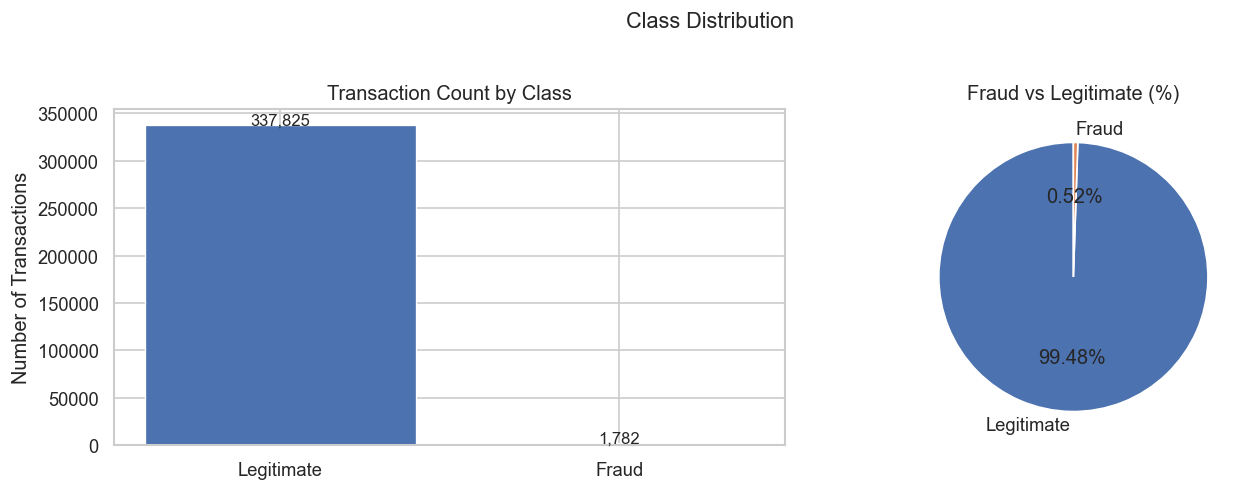

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
axes[0].bar(['Legitimate', 'Fraud'], fraud_counts.values,
            color=['#4C72B0', '#DD8452'], edgecolor='white', linewidth=0.8)
axes[0].set_title('Transaction Count by Class')
axes[0].set_ylabel('Number of Transactions')
for i, v in enumerate(fraud_counts.values):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontsize=10)

# Pie chart
axes[1].pie(fraud_counts.values, labels=['Legitimate', 'Fraud'],
            autopct='%1.2f%%', colors=['#4C72B0', '#DD8452'],
            startangle=90, wedgeprops=dict(edgecolor='white'))
axes[1].set_title('Fraud vs Legitimate (%)')

plt.suptitle('Class Distribution', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()




### 3.2 Fraud by Transaction Category

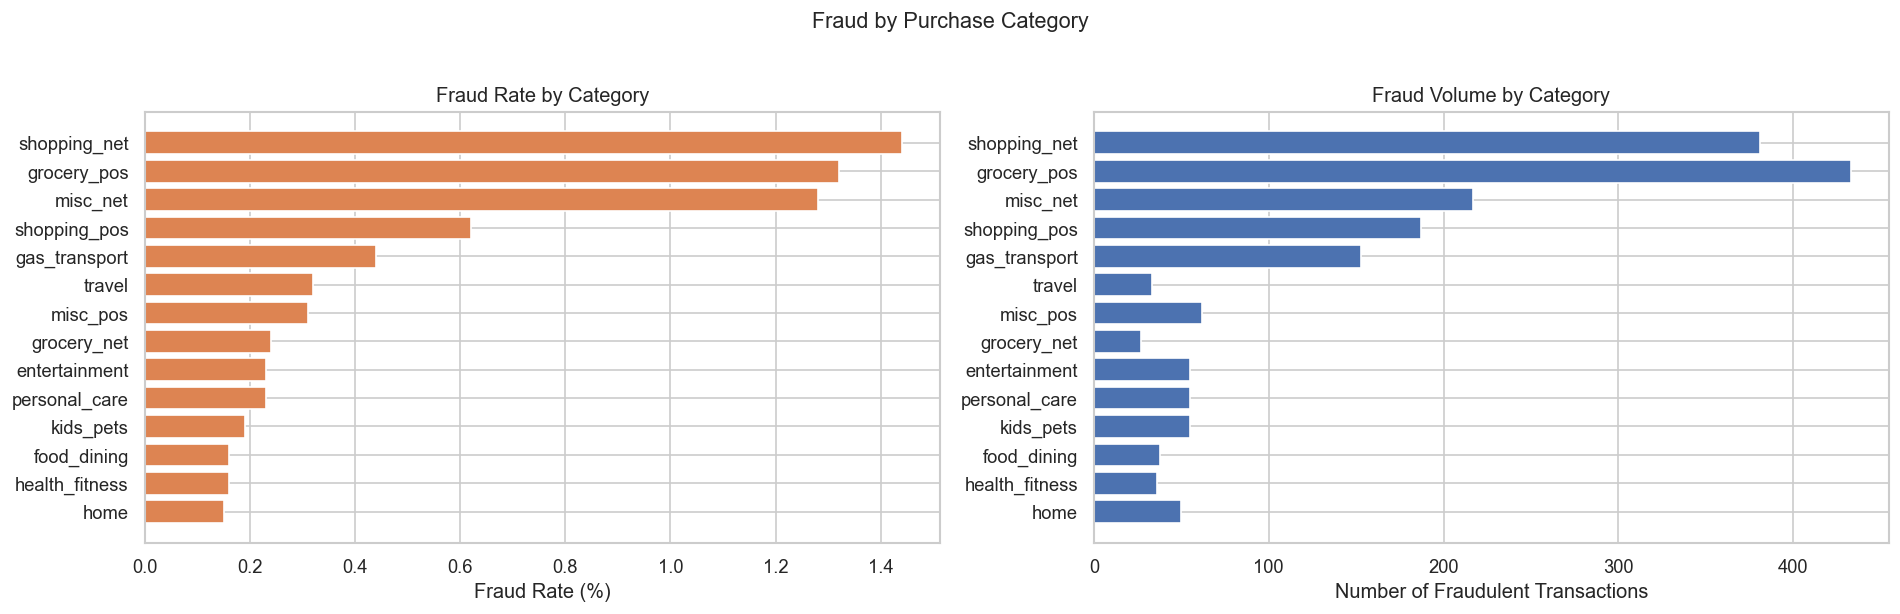

      Category  Fraud Count  Total  Fraud Rate (%)
  shopping_net          381  26379            1.44
   grocery_pos          433  32732            1.32
      misc_net          217  16898            1.28
  shopping_pos          187  30329            0.62
 gas_transport          153  35089            0.44
        travel           33  10322            0.32
      misc_pos           62  20024            0.31
   grocery_net           27  11355            0.24
 entertainment           55  24222            0.23
 personal_care           55  24406            0.23
     kids_pets           55  29704            0.19
   food_dining           38  23038            0.16
health_fitness           36  22593            0.16
          home           50  32516            0.15


In [8]:
# Fraud rate per category
cat_stats = df.groupby('category')['is_fraud'].agg(['sum', 'count'])
cat_stats['fraud_rate'] = (cat_stats['sum'] / cat_stats['count'] * 100).round(2)
cat_stats = cat_stats.sort_values('fraud_rate', ascending=False).reset_index()
cat_stats.columns = ['Category', 'Fraud Count', 'Total', 'Fraud Rate (%)']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Fraud rate
axes[0].barh(cat_stats['Category'], cat_stats['Fraud Rate (%)'],
             color='#DD8452', edgecolor='white')
axes[0].set_xlabel('Fraud Rate (%)')
axes[0].set_title('Fraud Rate by Category')
axes[0].invert_yaxis()

# Total fraud volume
axes[1].barh(cat_stats['Category'], cat_stats['Fraud Count'],
             color='#4C72B0', edgecolor='white')
axes[1].set_xlabel('Number of Fraudulent Transactions')
axes[1].set_title('Fraud Volume by Category')
axes[1].invert_yaxis()

plt.suptitle('Fraud by Purchase Category', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(cat_stats.to_string(index=False))


### 3.3 Transaction Amount: Fraudulent vs Legitimate Transactions

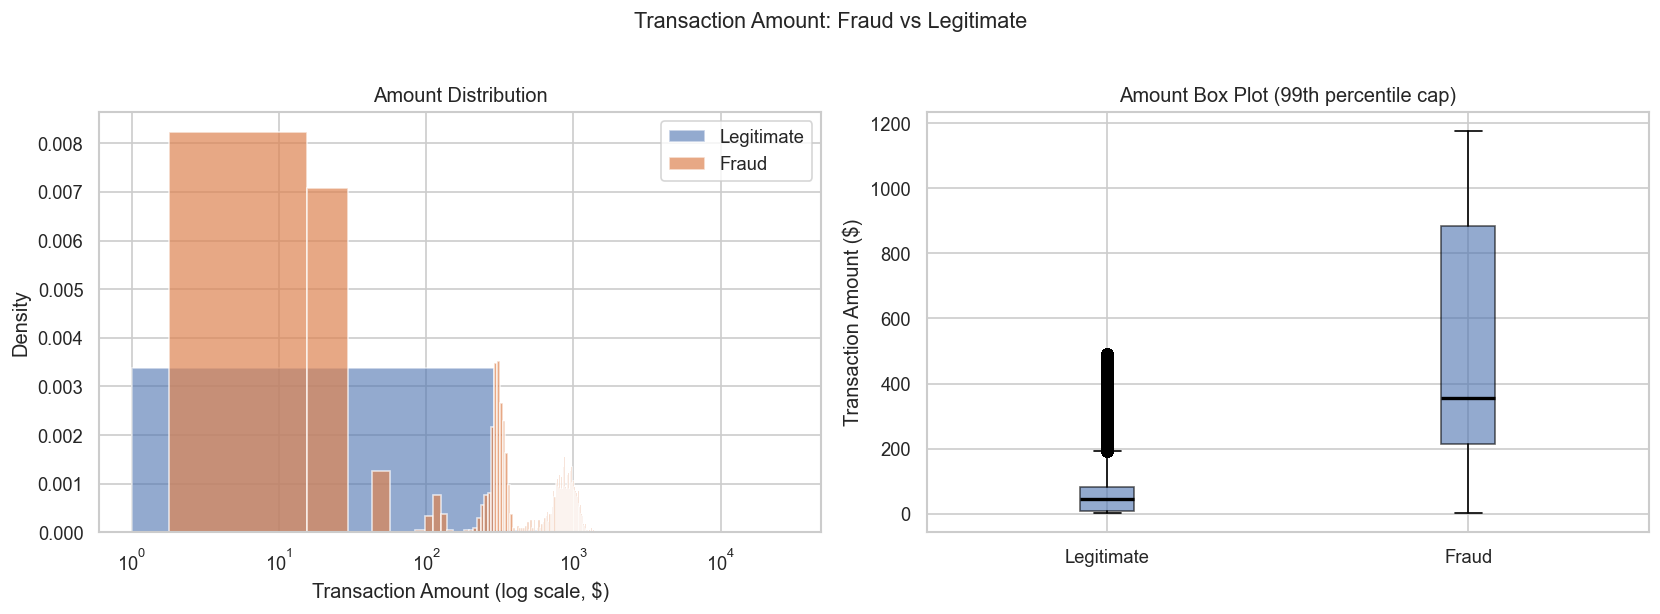

Median legitimate: $46.25  |  Median fraud: $356.44
Mean  legitimate: $68.22  |  Mean  fraud: $518.07


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fraud_amt  = df[df['is_fraud'] == 1]['amt']
legit_amt  = df[df['is_fraud'] == 0]['amt']

# Distribution (log scale for readability)
axes[0].hist(legit_amt, bins=100, alpha=0.6, label='Legitimate', color='#4C72B0', density=True)
axes[0].hist(fraud_amt, bins=100, alpha=0.7, label='Fraud',       color='#DD8452', density=True)
axes[0].set_xscale('log')
axes[0].set_xlabel('Transaction Amount (log scale, $)')
axes[0].set_ylabel('Density')
axes[0].set_title('Amount Distribution')
axes[0].legend()

# Box plot
data_box = [legit_amt.clip(upper=legit_amt.quantile(0.99)),
            fraud_amt.clip(upper=fraud_amt.quantile(0.99))]
axes[1].boxplot(data_box, labels=['Legitimate', 'Fraud'],
                patch_artist=True,
                boxprops=dict(facecolor='#4C72B0', alpha=0.6),
                medianprops=dict(color='black', linewidth=2))
axes[1].set_ylabel('Transaction Amount ($)')
axes[1].set_title('Amount Box Plot (99th percentile cap)')

plt.suptitle('Transaction Amount: Fraud vs Legitimate', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f"Median legitimate: ${legit_amt.median():.2f}  |  Median fraud: ${fraud_amt.median():.2f}")
print(f"Mean  legitimate: ${legit_amt.mean():.2f}  |  Mean  fraud: ${fraud_amt.mean():.2f}")


### 3.4 Age Analysis — Are Elderly Customers More at Risk?

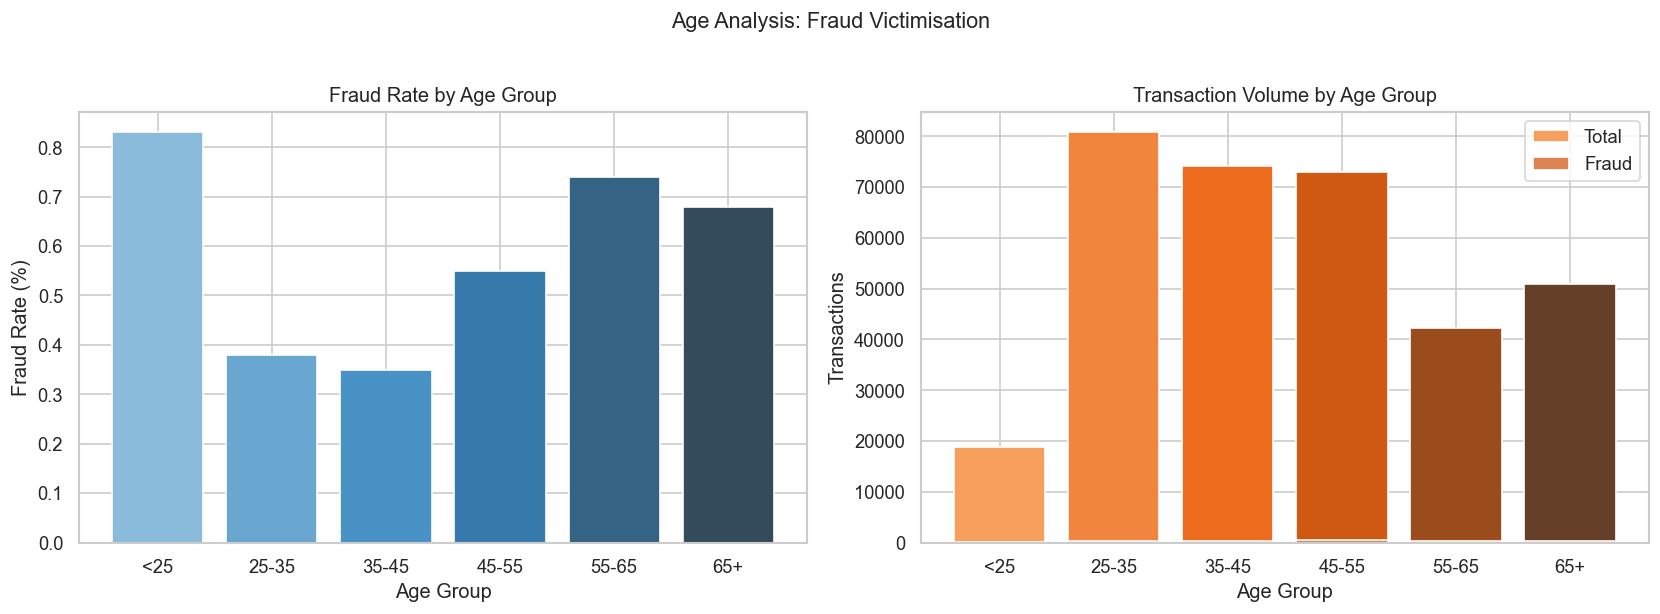

           Fraud Rate (%)  Fraud Count  Total
age_group                                    
<25                  0.83          156  18844
25-35                0.38          306  80740
35-45                0.35          260  74035
45-55                0.55          400  72976
55-65                0.74          313  42204
65+                  0.68          347  50808


In [10]:
# Derive age from date of birth
df['dob'] = pd.to_datetime(df['dob'])
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
df['age'] = ((df['trans_date_trans_time'] - df['dob']).dt.days / 365.25).astype(int)

# Bin into age groups
bins   = [0, 25, 35, 45, 55, 65, 120]
labels = ['<25', '25-35', '35-45', '45-55', '55-65', '65+']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels)

age_fraud = df.groupby('age_group', observed=True)['is_fraud'].agg(['mean', 'sum', 'count'])
age_fraud['fraud_rate_pct'] = (age_fraud['mean'] * 100).round(2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Fraud rate by age group
axes[0].bar(age_fraud.index, age_fraud['fraud_rate_pct'],
            color=sns.color_palette('Blues_d', len(age_fraud)), edgecolor='white')
axes[0].set_xlabel('Age Group')
axes[0].set_ylabel('Fraud Rate (%)')
axes[0].set_title('Fraud Rate by Age Group')

# Transaction count by age group
axes[1].bar(age_fraud.index, age_fraud['count'],
            color=sns.color_palette('Oranges_d', len(age_fraud)), edgecolor='white', label='Total')
axes[1].bar(age_fraud.index, age_fraud['sum'],
            color='#DD8452', edgecolor='white', label='Fraud')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Transactions')
axes[1].set_title('Transaction Volume by Age Group')
axes[1].legend()

plt.suptitle('Age Analysis: Fraud Victimisation', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(age_fraud[['fraud_rate_pct', 'sum', 'count']].rename(
    columns={'fraud_rate_pct': 'Fraud Rate (%)', 'sum': 'Fraud Count', 'count': 'Total'}))


### 3.5 Geospatial Fraud Rate by State

In [11]:
# Fraud rate per state
state_fraud = df.groupby('state')['is_fraud'].agg(['mean', 'sum', 'count']).reset_index()
state_fraud.columns = ['state', 'fraud_rate', 'fraud_count', 'total']
state_fraud['fraud_rate_pct'] = (state_fraud['fraud_rate'] * 100).round(3)

fig = px.choropleth(
    state_fraud,
    locations='state',
    locationmode='USA-states',
    color='fraud_rate_pct',
    scope='usa',
    color_continuous_scale='Reds',
    title='Fraud Rate (%) by State — Western United States',
    labels={'fraud_rate_pct': 'Fraud Rate (%)'},
    hover_data={'fraud_count': True, 'total': True}
)
fig.update_layout(margin=dict(l=0, r=0, t=40, b=0))
fig.show()

print("\nTop 5 states by fraud rate:")
print(state_fraud.sort_values('fraud_rate_pct', ascending=False).head(5)[
    ['state', 'fraud_rate_pct', 'fraud_count', 'total']].to_string(index=False))



Top 5 states by fraud rate:
state  fraud_rate_pct  fraud_count  total
   AK           1.687           50   2963
   OR           0.746          197  26408
   NE           0.627          216  34425
   CO           0.582          115  19766
   NM           0.516          121  23427


### 3.6 Fraud by Hour of Day

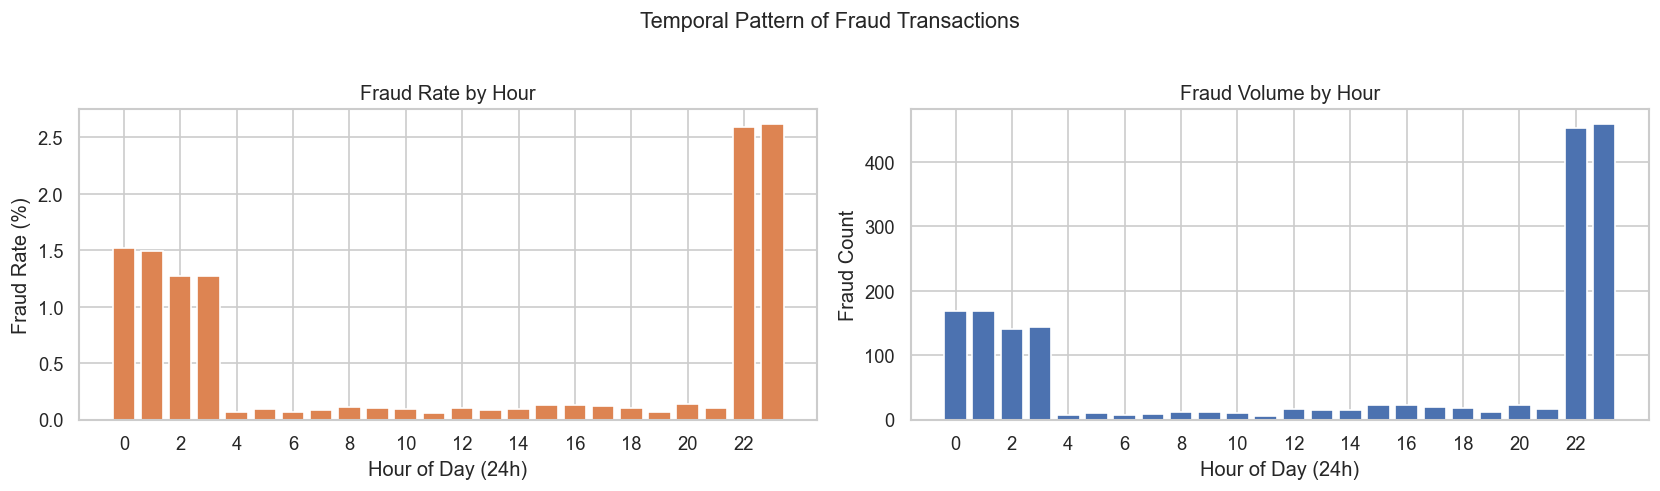

In [12]:
df['hour'] = df['trans_date_trans_time'].dt.hour

hourly = df.groupby('hour')['is_fraud'].agg(['mean', 'sum']).reset_index()
hourly.columns = ['hour', 'fraud_rate', 'fraud_count']

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(hourly['hour'], hourly['fraud_rate'] * 100, color='#DD8452', edgecolor='white')
axes[0].set_xlabel('Hour of Day (24h)')
axes[0].set_ylabel('Fraud Rate (%)')
axes[0].set_title('Fraud Rate by Hour')
axes[0].set_xticks(range(0, 24, 2))

axes[1].bar(hourly['hour'], hourly['fraud_count'], color='#4C72B0', edgecolor='white')
axes[1].set_xlabel('Hour of Day (24h)')
axes[1].set_ylabel('Fraud Count')
axes[1].set_title('Fraud Volume by Hour')
axes[1].set_xticks(range(0, 24, 2))

plt.suptitle('Temporal Pattern of Fraud Transactions', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


## 4. Feature Engineering & Data Preprocessing


In [ ]:

df['hour']      = df['trans_date_trans_time'].dt.hour
df['day_of_week'] = df['trans_date_trans_time'].dt.dayofweek
df['month']     = df['trans_date_trans_time'].dt.month

# Distance between customer home and merchant (Haversine approximation)
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius km
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi   = np.radians(lat2 - lat1)
    dlambda= np.radians(lon2 - lon1)
    a = np.sin(dphi/2)**2 + np.cos(phi1)*np.cos(phi2)*np.sin(dlambda/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

df['distance_km'] = haversine(df['lat'], df['long'], df['merch_lat'], df['merch_long'])

# Encode categoricals
le = LabelEncoder()
df['category_enc'] = le.fit_transform(df['category'])

print("Feature engineering complete.")
print(f"New features added: hour, day_of_week, month, distance_km, category_enc, age")


Feature engineering complete.
New features added: hour, day_of_week, month, distance_km, category_enc, age


In [ ]:
# ── Select features for modelling ────────
FEATURES = [
    'amt', 'age', 'hour', 'day_of_week', 'month',
    'distance_km', 'category_enc',
    'city_pop', 'lat', 'long', 'merch_lat', 'merch_long'
]

TARGET = 'is_fraud'

X = df[FEATURES]
y = df[TARGET]

print(f"Feature matrix shape : {X.shape}")
print(f"Target distribution  : {y.value_counts().to_dict()}")


Feature matrix shape : (339607, 12)
Target distribution  : {0: 337825, 1: 1782}


In [ ]:
# ── Train / Test split (stratified to preserve class ratio) ──
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size : {len(X_train):,}  |  Fraud in train: {y_train.sum():,} ({y_train.mean()*100:.2f}%)")
print(f"Test size  : {len(X_test):,}   |  Fraud in test:  {y_test.sum():,} ({y_test.mean()*100:.2f}%)")


Train size : 271,685  |  Fraud in train: 1,426 (0.52%)
Test size  : 67,922   |  Fraud in test:  356 (0.52%)


## 5. Model Implementation

| Model 
|---
| Logistic Regression 
| Random Forest 
| XGBoost 



In [ ]:
# ── Helper: evaluate and store results ──
results = {}

def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]

    results[name] = {
        'model'    : model,
        'y_pred'   : y_pred,
        'y_prob'   : y_prob,
        'recall'   : recall_score(y_te, y_pred),
        'precision': precision_score(y_te, y_pred),
        'f1'       : f1_score(y_te, y_pred),
        'roc_auc'  : roc_auc_score(y_te, y_prob),
    }
    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(classification_report(y_te, y_pred, target_names=['Legitimate', 'Fraud']))
    return results[name]


### 5.1 Logistic Regression (Baseline)

In [17]:
lr_pipe = ImbPipeline([
    ('smote',  SMOTE(random_state=42)),
    ('scaler', StandardScaler()),
    ('model',  LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
])

evaluate_model('Logistic Regression', lr_pipe, X_train, y_train, X_test, y_test)



  Logistic Regression
              precision    recall  f1-score   support

  Legitimate       1.00      0.93      0.96     67566
       Fraud       0.05      0.72      0.10       356

    accuracy                           0.93     67922
   macro avg       0.53      0.83      0.53     67922
weighted avg       0.99      0.93      0.96     67922



{'model': Pipeline(steps=[('smote', SMOTE(random_state=42)), ('scaler', StandardScaler()),
                 ('model',
                  LogisticRegression(class_weight='balanced', max_iter=1000,
                                     random_state=42))]),
 'y_pred': array([1, 0, 0, ..., 0, 0, 0], shape=(67922,)),
 'y_prob': array([0.65176739, 0.18737558, 0.18822705, ..., 0.26286898, 0.16411858,
        0.18734749], shape=(67922,)),
 'recall': 0.7191011235955056,
 'precision': 0.05387205387205387,
 'f1': 0.10023492560689115,
 'roc_auc': 0.8469759239987401}

### 5.2 Random Forest

In [18]:
rf_pipe = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', RandomForestClassifier(
        n_estimators=100,
        class_weight='balanced',
        max_depth=20,
        min_samples_leaf=5,
        n_jobs=-1,
        random_state=42
    ))
])

evaluate_model('Random Forest', rf_pipe, X_train, y_train, X_test, y_test)



  Random Forest
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     67566
       Fraud       0.51      0.79      0.62       356

    accuracy                           0.99     67922
   macro avg       0.75      0.90      0.81     67922
weighted avg       1.00      0.99      1.00     67922



{'model': Pipeline(steps=[('smote', SMOTE(random_state=42)),
                 ('model',
                  RandomForestClassifier(class_weight='balanced', max_depth=20,
                                         min_samples_leaf=5, n_jobs=-1,
                                         random_state=42))]),
 'y_pred': array([0, 0, 0, ..., 0, 0, 0], shape=(67922,)),
 'y_prob': array([2.28232166e-02, 5.66666667e-03, 4.42995967e-02, ...,
        6.27939595e-06, 1.62697489e-01, 1.06815685e-01], shape=(67922,)),
 'recall': 0.7949438202247191,
 'precision': 0.5053571428571428,
 'f1': 0.6179039301310044,
 'roc_auc': 0.9848294817518418}

### 5.3 XGBoost

In [19]:
# Calculate scale_pos_weight to handle imbalance without SMOTE
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale = neg / pos
print(f"scale_pos_weight = {scale:.1f}  (boosts minority class weight)")

xgb_pipe = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        scale_pos_weight=scale,
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1
    ))
])

evaluate_model('XGBoost', xgb_pipe, X_train, y_train, X_test, y_test)


scale_pos_weight = 189.5  (boosts minority class weight)

  XGBoost
              precision    recall  f1-score   support

  Legitimate       1.00      0.88      0.94     67566
       Fraud       0.04      0.96      0.08       356

    accuracy                           0.88     67922
   macro avg       0.52      0.92      0.51     67922
weighted avg       0.99      0.88      0.93     67922



{'model': Pipeline(steps=[('smote', SMOTE(random_state=42)),
                 ('model',
                  XGBClassifier(base_score=None, booster=None, callbacks=None,
                                colsample_bylevel=None, colsample_bynode=None,
                                colsample_bytree=None, device=None,
                                early_stopping_rounds=None,
                                enable_categorical=False, eval_metric='logloss',
                                feature_types=None, feature_weights=None,
                                gamma=None, grow_policy=None,
                                importance_type=None,
                                interaction_constraints=None, learning_rate=0.1,
                                max_bin=None, max_cat_threshold=None,
                                max_cat_to_onehot=None, max_delta_step=None,
                                max_depth=6, max_leaves=None,
                                min_child_weight=None, missing=na

## 6. Experimental Evaluation & Model Comparison

We now compare all three models.


### 6.1 Metrics Summary Table

In [20]:
summary = pd.DataFrame({
    name: {
        'Recall'    : f"{v['recall']:.4f}",
        'Precision' : f"{v['precision']:.4f}",
        'F1 Score'  : f"{v['f1']:.4f}",
        'ROC-AUC'   : f"{v['roc_auc']:.4f}",
    }
    for name, v in results.items()
}).T

print("\nModel Comparison Summary:")
print(summary.to_string())



Model Comparison Summary:
                     Recall Precision F1 Score ROC-AUC
Logistic Regression  0.7191    0.0539   0.1002  0.8470
Random Forest        0.7949    0.5054   0.6179  0.9848
XGBoost              0.9607    0.0412   0.0790  0.9793


### 6.2 Confusion Matrices

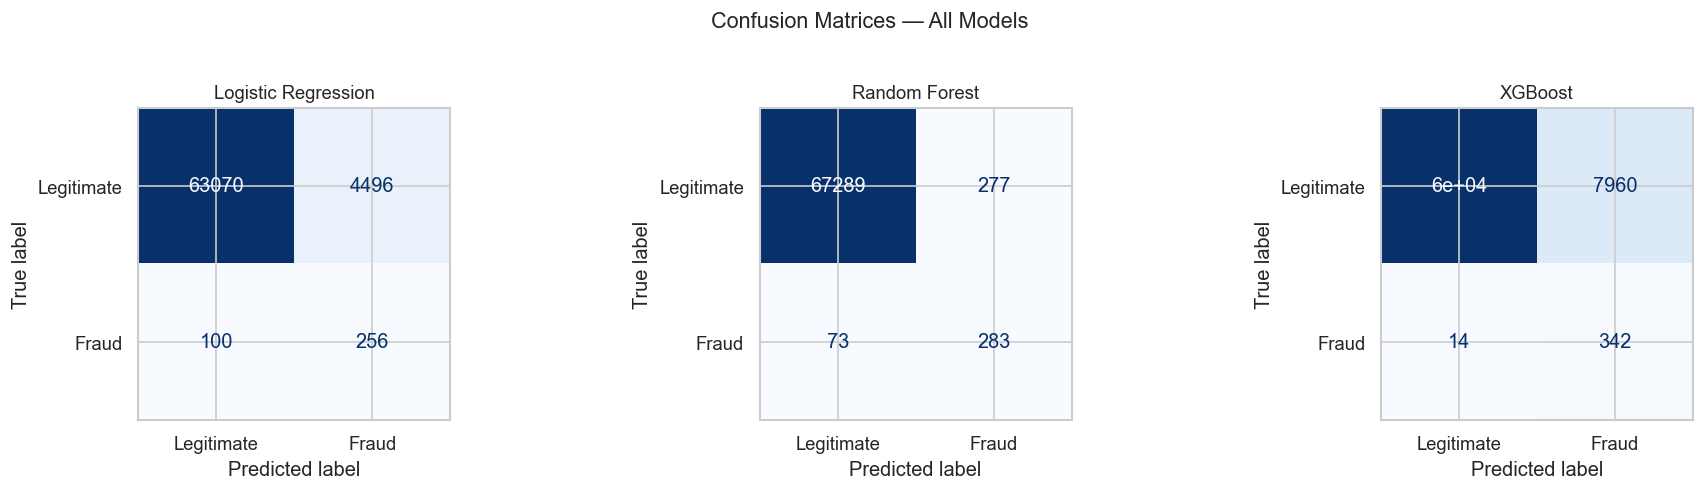

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    disp = ConfusionMatrixDisplay(cm, display_labels=['Legitimate', 'Fraud'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=11)

plt.suptitle('Confusion Matrices — All Models', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


### 6.3 ROC Curves

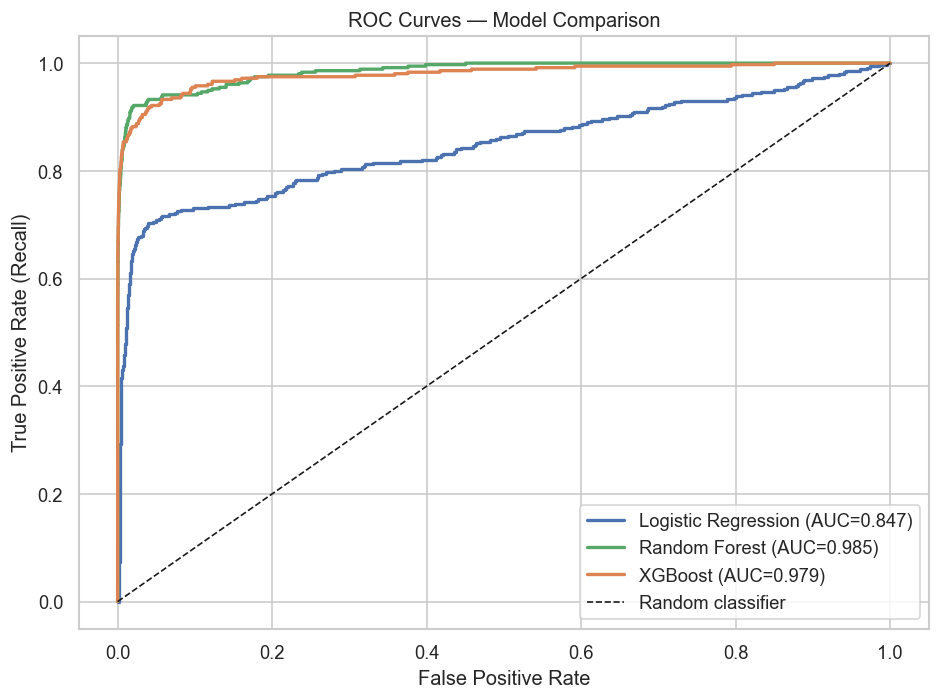

In [22]:
fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#4C72B0', '#55A868', '#DD8452']

for (name, res), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    ax.plot(fpr, tpr, label=f"{name} (AUC={res['roc_auc']:.3f})", color=color, lw=2)

ax.plot([0,1], [0,1], 'k--', lw=1, label='Random classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate (Recall)')
ax.set_title('ROC Curves — Model Comparison')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()


### 6.4 Precision-Recall Curves

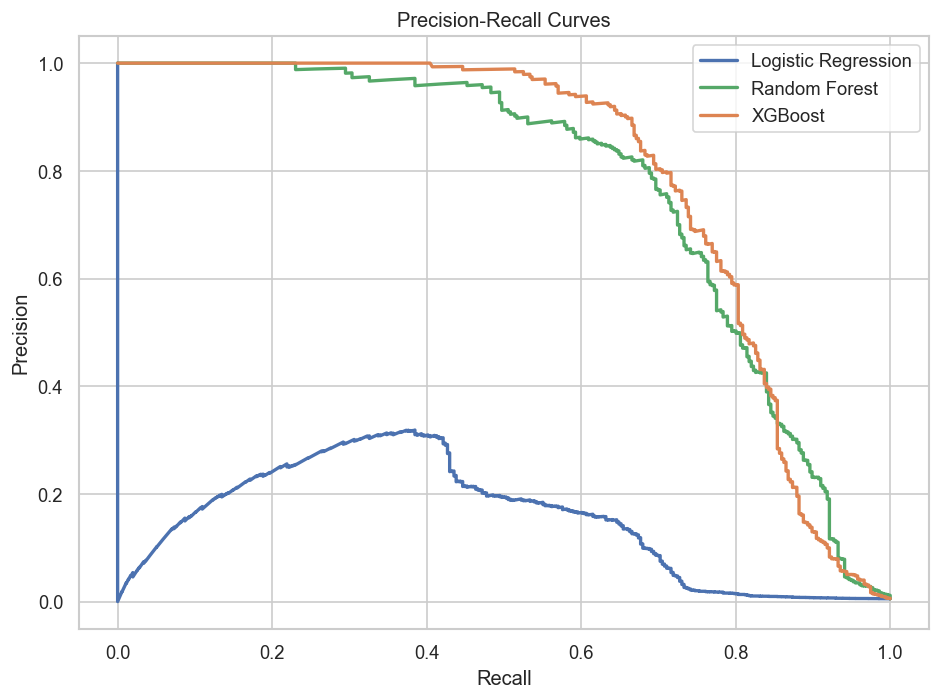

In [30]:
fig, ax = plt.subplots(figsize=(8, 6))

for (name, res), color in zip(results.items(), colors):
    prec, rec, _ = precision_recall_curve(y_test, res['y_prob'])
    ax.plot(rec, prec, label=name, color=color, lw=2)

ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curves')
ax.legend()
plt.tight_layout()
plt.show()



### 6.5 Feature Importance (Random Forest & XGBoost)

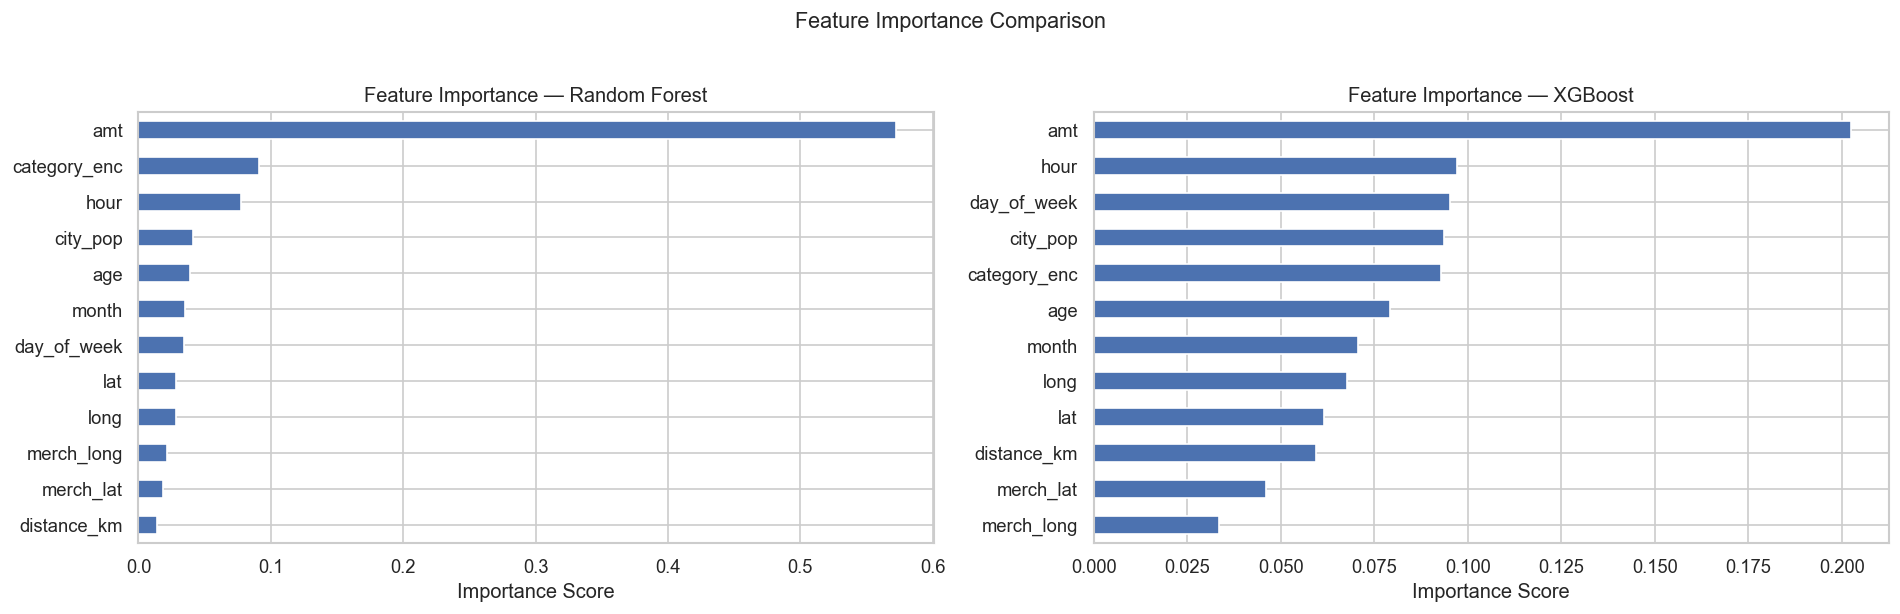

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, name in zip(axes, ['Random Forest', 'XGBoost']):
    # Get the final step of the pipeline
    model_step = results[name]['model'].named_steps['model']
    importances = model_step.feature_importances_
    feat_imp = pd.Series(importances, index=FEATURES).sort_values(ascending=True)

    feat_imp.plot(kind='barh', ax=ax, color='#4C72B0', edgecolor='white')
    ax.set_title(f'Feature Importance — {name}')
    ax.set_xlabel('Importance Score')

plt.suptitle('Feature Importance Comparison', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


### 6.6 Cross-Validation (Best Model)

In [25]:
# Run 5-fold stratified cross-validation on the best model

best_name = 'Random Forest'  
best_pipe  = results[best_name]['model']

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_recall = cross_val_score(best_pipe, X_train, y_train, cv=cv, scoring='recall', n_jobs=-1)
cv_f1     = cross_val_score(best_pipe, X_train, y_train, cv=cv, scoring='f1',     n_jobs=-1)
cv_auc    = cross_val_score(best_pipe, X_train, y_train, cv=cv, scoring='roc_auc',n_jobs=-1)

print(f"Cross-Validation Results — {best_name} (5-fold Stratified)")
print(f"{'Metric':<12} {'Mean':>8} {'Std':>8}")
print("-" * 30)
print(f"{'Recall':<12} {cv_recall.mean():>8.4f} {cv_recall.std():>8.4f}")
print(f"{'F1 Score':<12} {cv_f1.mean():>8.4f} {cv_f1.std():>8.4f}")
print(f"{'ROC-AUC':<12} {cv_auc.mean():>8.4f} {cv_auc.std():>8.4f}")


Cross-Validation Results — Random Forest (5-fold Stratified)
Metric           Mean      Std
------------------------------
Recall         0.8072   0.0159
F1 Score       0.6048   0.0106
ROC-AUC        0.9840   0.0053


## 7. Threshold Tuning


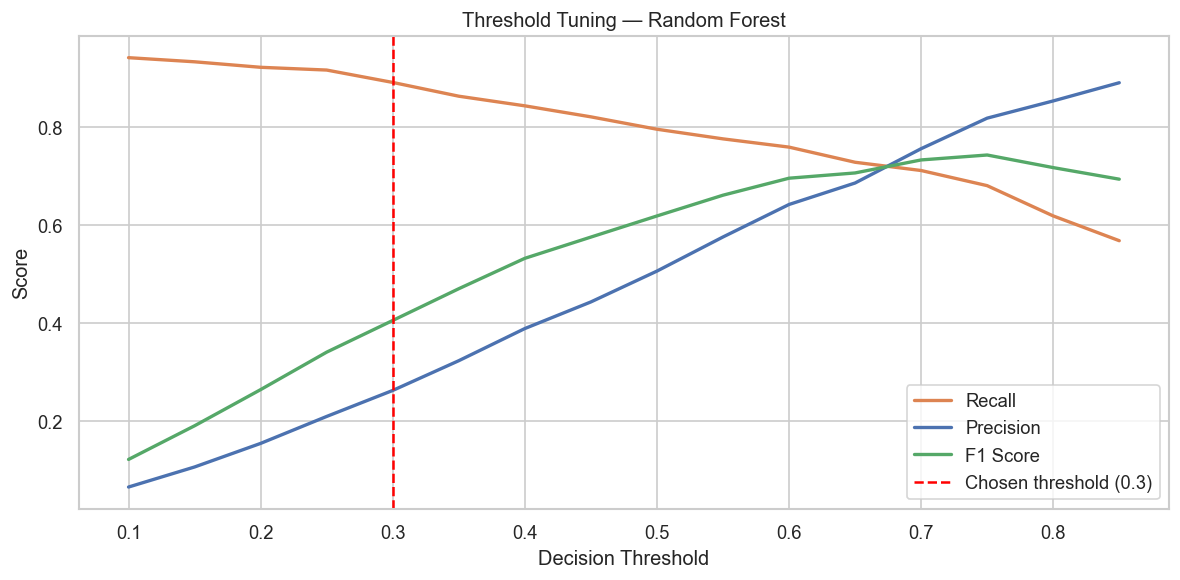

In [31]:
best_probs = results[best_name]['y_prob']

thresholds = np.arange(0.1, 0.9, 0.05)
thresh_results = []

for t in thresholds:
    y_pred_t = (best_probs >= t).astype(int)
    thresh_results.append({
        'threshold' : round(t, 2),
        'recall'    : recall_score(y_test, y_pred_t),
        'precision' : precision_score(y_test, y_pred_t, zero_division=0),
        'f1'        : f1_score(y_test, y_pred_t, zero_division=0),
    })

thresh_df = pd.DataFrame(thresh_results)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresh_df['threshold'], thresh_df['recall'],    label='Recall',    color='#DD8452', lw=2)
ax.plot(thresh_df['threshold'], thresh_df['precision'], label='Precision', color='#4C72B0', lw=2)
ax.plot(thresh_df['threshold'], thresh_df['f1'],        label='F1 Score',  color='#55A868', lw=2)
ax.axvline(x=0.3, color='red', linestyle='--', lw=1.5, label='Chosen threshold (0.3)')
ax.set_xlabel('Decision Threshold')
ax.set_ylabel('Score')
ax.set_title(f'Threshold Tuning — {best_name}')
ax.legend()
plt.tight_layout()
plt.show()



In [27]:
# Apply chosen threshold
THRESHOLD = 0.3
y_pred_tuned = (best_probs >= THRESHOLD).astype(int)

print(f"Results at threshold = {THRESHOLD}:")
print(classification_report(y_test, y_pred_tuned, target_names=['Legitimate', 'Fraud']))


Results at threshold = 0.3:
              precision    recall  f1-score   support

  Legitimate       1.00      0.99      0.99     67566
       Fraud       0.26      0.89      0.40       356

    accuracy                           0.99     67922
   macro avg       0.63      0.94      0.70     67922
weighted avg       1.00      0.99      0.99     67922



## 8. Save Model for Deployment

We save the best model and threshold so the Streamlit app can load them without retraining.


In [28]:
import joblib

# save label encoder (Streamlit will need this to decode category names)
joblib.dump(le, "label_encoder.pkl")

# Save the trained pipeline
joblib.dump(results[best_name]['model'], 'fraud_model.pkl')

# Save feature list and threshold (Streamlit will need these)
import json
config = {
    'features'  : FEATURES,
    'threshold' : THRESHOLD,
    'model_name': best_name
}
with open('model_config.json', 'w') as f:
    json.dump(config, f, indent=2)

print(f"Model saved     : fraud_model.pkl")
print(f"Label Encoder saved: label_encoder.pkl")
print(f"Config saved    : model_config.json")
print(f"\nConfig contents:\n{json.dumps(config, indent=2)}")


Model saved     : fraud_model.pkl
Label Encoder saved: label_encoder.pkl
Config saved    : model_config.json

Config contents:
{
  "features": [
    "amt",
    "age",
    "hour",
    "day_of_week",
    "month",
    "distance_km",
    "category_enc",
    "city_pop",
    "lat",
    "long",
    "merch_lat",
    "merch_long"
  ],
  "threshold": 0.3,
  "model_name": "Random Forest"
}
